# Looqbox Challenge Test

## SQL Test

### Conection

In [6]:
# Conection

from sqlalchemy import create_engine
import pandas as pd

HOST = "35.199.115.174"
USER = "looqbox-challenge"
PASSWORD = "looq-challenge"
DB = "looqbox-challenge"

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DB}"
)

pd.read_sql("SHOW TABLES;", engine)

,Tables_in_looqbox-challenge
0,IMDB_movies
1,data_product
2,data_product_sales
3,data_store_cad
4,data_store_sales


In [20]:
query = """
SELECT * FROM data_product
LIMIT 5;
"""

test = pd.read_sql(query, engine)
test

,PRODUCT_COD,PRODUCT_NAME,PRODUCT_VAL,DEP_NAME,DEP_COD,SECTION_NAME,SECTION_COD
0,10,Acido Tranexamico 250mg Generico EMS 12 Compri...,36.71,MEDICAMENTOS GENÉRICOS,10,CIRCULAÇÃO,40
1,11,Bissulfato de Clopidogrel 75mg Generico Teuto ...,66.51,MEDICAMENTOS GENÉRICOS,10,CIRCULAÇÃO,40
2,12,Cloridrato de Amiodarona 200mg Generico Biosin...,31.17,MEDICAMENTOS GENÉRICOS,10,CIRCULAÇÃO,40
3,13,Acido Tranexâmico 250mg Generico Legrand 12 Co...,36.71,MEDICAMENTOS GENÉRICOS,10,CIRCULAÇÃO,40
4,14,Cloridrato Oximetazolina Adulto 5mg/ml Genéric...,12.08,MEDICAMENTOS GENÉRICOS,10,GRIPES E RESFRIADOS,41


### 1. Top 10 most expensive products

In [21]:
query = """
SELECT
    PRODUCT_COD,
    PRODUCT_NAME,
    PRODUCT_VAL
FROM data_product
ORDER BY PRODUCT_VAL DESC
LIMIT 10;
"""

top_10_products = pd.read_sql(query, engine)
display(top_10_products)



,PRODUCT_COD,PRODUCT_NAME,PRODUCT_VAL
0,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99
1,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90
2,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00
3,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90
4,320046,Escova Dental Eletrica ORAL B D34 Professional...,399.90
5,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90
6,153795,Champagne Frances Brut Imperial MOET Rose Garr...,359.90
7,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00
8,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90
9,154431,Champagne Frances Brut Imperial MOET & CHANDON...,315.90


### 2. Sections of 'BEBIDAS' and 'PADARIA'

In [22]:
query = """
SELECT DISTINCT
    DEP_NAME,
    SECTION_NAME
FROM data_product   
WHERE DEP_NAME IN ('BEBIDAS', 'PADARIA')
ORDER BY DEP_NAME, SECTION_NAME;
"""

sections = pd.read_sql(query, engine)
sections

,DEP_NAME,SECTION_NAME
0,BEBIDAS,BEBIDAS
1,BEBIDAS,CERVEJAS
2,BEBIDAS,REFRESCOS
3,BEBIDAS,VINHOS
4,PADARIA,DOCES-E-SOBREMESAS
5,PADARIA,GESTANTE
6,PADARIA,PADARIA
7,PADARIA,QUEIJOS-E-FRIOS


### 3. Total sale of products (in $) of each Business Area in the first quarter of 2019

In [23]:
query = """
SELECT
    c.BUSINESS_NAME,
    c.BUSINESS_CODE,
    SUM(s.SALES_VALUE) AS TOTAL_SALES_VALUE
FROM data_store_sales s
LEFT JOIN data_store_cad c
    ON s.STORE_CODE = c.STORE_CODE
WHERE s.DATE BETWEEN '2019-01-01' AND '2019-03-31'
GROUP BY
    c.BUSINESS_NAME,
    c.BUSINESS_CODE
ORDER BY TOTAL_SALES_VALUE DESC;
"""

sales_by_business = pd.read_sql(query, engine)
sales_by_business

,BUSINESS_NAME,BUSINESS_CODE,TOTAL_SALES_VALUE
0,Farma,4,81776691.73
1,Varejo,1,81032347.65
2,Atacado,5,80384884.60
3,Proximidade,2,80171122.80
4,Posto,3,32072326.40


## Case 1

In [ ]:
# dynamic function that uses a combination of product, store and date period --- user only inform the params

def retrieve_data(product_code=None, store_code=None, date=None):
    """
    Retrieves all columns from data_product_sales using optional filters.

    Parameters
    ----------
    product_code : int, optional
    store_code : int, optional
    date : list[str], optional
    Example: ['2019-01-01', '2019-01-31']

    Returns
    -------
    pandas.DataFrame
    """

    query = "SELECT * FROM data_product_sales WHERE 1=1"
    params = {}

    # I used AI to help me setup the params code

    if product_code is not None:
        query += " AND PRODUCT_CODE = :product_code"
        params["product_code"] = product_code

    if store_code is not None:
        query += " AND STORE_CODE = :store_code"
        params["store_code"] = store_code

    if date is not None:
        if len(date) != 2:
            raise ValueError("date must be a list with two values: [start_date, end_date]")

        query += " AND DATE BETWEEN :start_date AND :end_date"
        params["start_date"] = date[0]
        params["end_date"] = date[1]

    return pd.read_sql(text(query), engine, params=params)

In [68]:
# Test

my_data = retrieve_data(
    product_code=10,
    store_code=10,
    date=['2019-01-01', '2019-01-31']
)

my_data.head()

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,10,10,2019-01-01,2386.15,65.0
1,10,10,2019-01-02,4368.49,119.0
2,10,10,2019-01-03,3854.55,105.0
3,10,10,2019-01-04,3671.00,100.0
4,10,10,2019-01-05,3010.22,82.0


## Case 2

In [ ]:
query1 = """
SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad
"""

query2 = """
SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
"""

stores = pd.read_sql(query1, engine)
sales = pd.read_sql(query2, engine)

In [27]:
sales["DATE"] = pd.to_datetime(sales["DATE"])

sales_filtered = sales[
    (sales["DATE"] >= "2019-10-01") &
    (sales["DATE"] <= "2019-12-31")
]

In [28]:
df_case2 = sales_filtered.merge(
    stores,
    on="STORE_CODE",
    how="left"
)

In [ ]:
summary_case2 = (
    df_case2
    .groupby(["STORE_NAME", "BUSINESS_NAME"], as_index=False)
    .agg(
        SALES_VALUE=("SALES_VALUE", "sum"),
        SALES_QTY=("SALES_QTY", "sum")
    )
)

# I used AI to understand what "TM" means!

summary_case2["TM"] = summary_case2["SALES_VALUE"] / summary_case2["SALES_QTY"]

summary_case2.sort_values("STORE_NAME")

,STORE_NAME,BUSINESS_NAME,SALES_VALUE,SALES_QTY,TM
0,Bahia,Atacado,21213088.57,1378476,15.388798
1,Bangkok,Posto,8376271.00,612968,13.665103
2,Belem,Proximidade,20989553.37,1365988,15.365840
3,Berlin,Proximidade,21213088.57,1378476,15.388798
4,Buenos Aires,Atacado,21213088.57,1378476,15.388798
5,Chicago,Varejo,21928421.28,1412372,15.525953
6,Dubai,Atacado,21213088.57,1378476,15.388798
7,Hong Kong,Farma,15039911.54,570745,26.351368
8,London,Farma,19471788.15,671638,28.991493
9,Madri,Farma,24129399.10,831168,29.030712


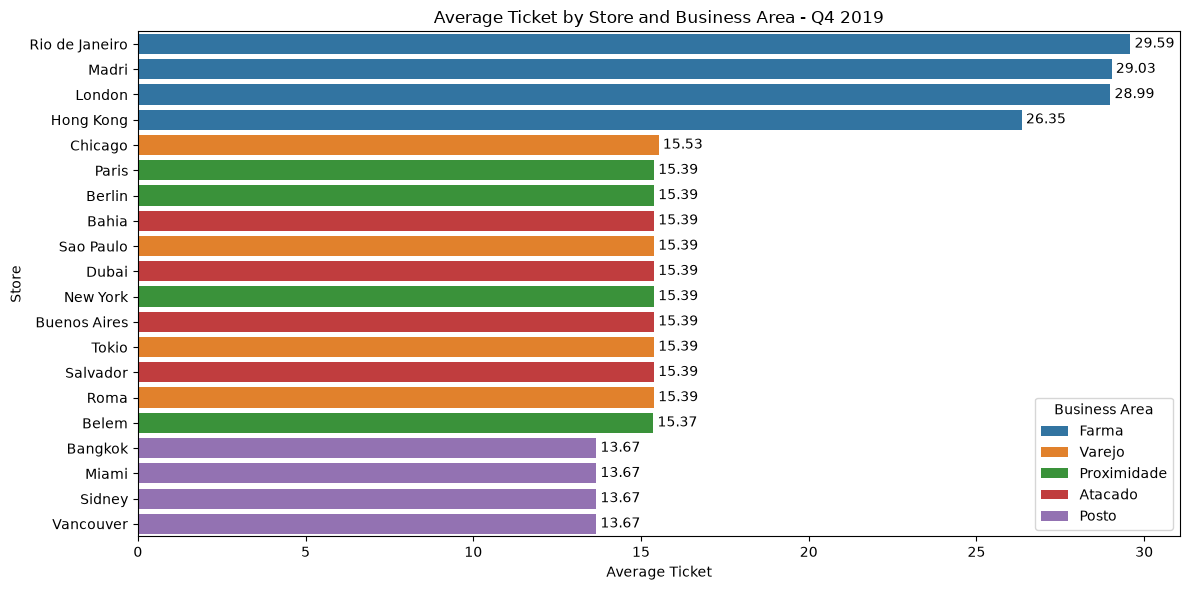

In [ ]:
# Chart ---

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

aux = sns.barplot(
    data=summary_case2.sort_values("TM", ascending=False),
    x="TM",
    y="STORE_NAME",
    hue="BUSINESS_NAME"
)

# I used AI to create the label format code!
for container in aux.containers:
    aux.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.title("Average Ticket by Store and Business Area - Q4 2019")
plt.xlabel("Average Ticket")
plt.ylabel("Store")
plt.legend(title="Business Area")
plt.tight_layout()
plt.show()

## Case 3

In [33]:
pd.read_sql("DESCRIBE IMDB_movies;", engine)

,Field,Type,Null,Key,Default,Extra
0,Id,int,NO,PRI,None,
1,Title,varchar(255),YES,,None,
2,Genre,varchar(255),YES,,None,
3,Director,varchar(255),YES,,None,
4,Actors,varchar(255),YES,,None,
5,Year,int,YES,,None,
6,Runtime,int,YES,,None,
7,Rating,"decimal(10,0)",YES,,None,
8,Votes,int,YES,,None,
9,RevenueMillions,"decimal(10,0)",YES,,None,


In [34]:
imdb = pd.read_sql("SELECT * FROM IMDB_movies;", engine)

imdb.head()

,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.0,157606,138.0,62.0
3,4,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.0,60545,270.0,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.0,393727,325.0,40.0


In [41]:
# Chart --- Top 10 Highest Grossing Movies

top10_revenue = (
    imdb[['Title', 'RevenueMillions']]
    .dropna()
    .sort_values('RevenueMillions', ascending=False)
    .head(10)
)

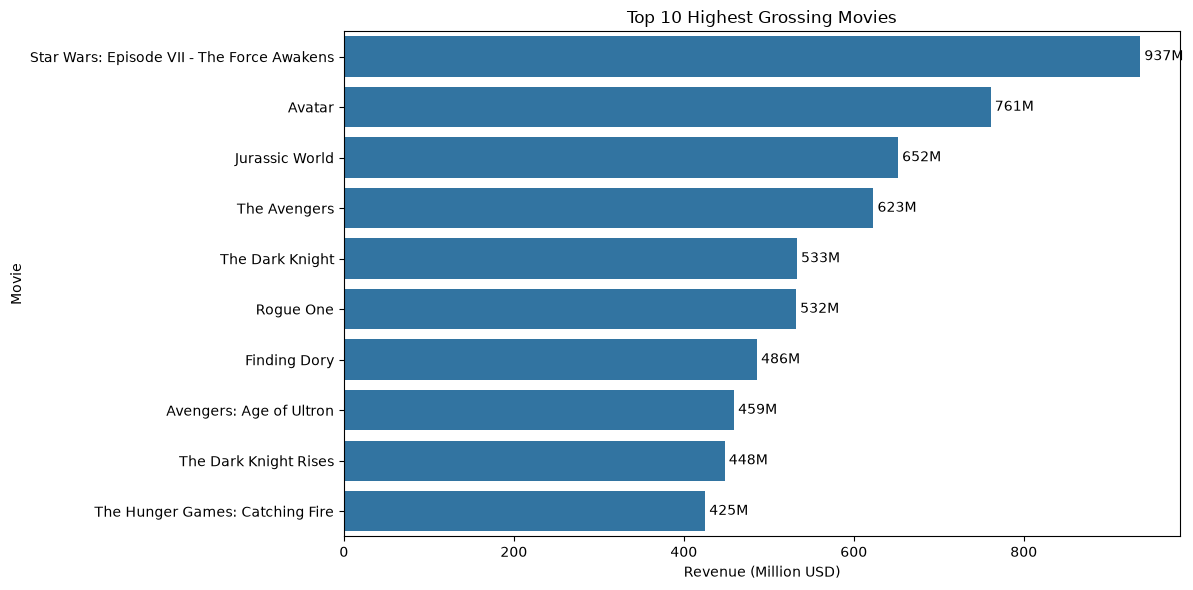

In [ ]:

plt.figure(figsize=(12, 6))

aux = sns.barplot(
    data=top10_revenue,
    x='RevenueMillions',
    y='Title'
)

# I used AI to create the label format code!
for container in aux.containers:
    labels = [
        f'{v:,.0f}M'
        for v in container.datavalues
    ]

    aux.bar_label(
        container,
        labels=labels,
        padding=3
    )

plt.title('Top 10 Highest Grossing Movies')
plt.xlabel('Revenue (Million USD)')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()